In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv('zuu crew scores.csv')
df.head(5)

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
3,Nisal Gamage,1,74.5,63.9,7,0,76.8,1.7,Production-Ready ML Systems,100.0
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1


In [25]:
df = df[df['CourseName'] == 'Foundations of ML']
df.head()

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2


In [26]:
df['Passed'] = df['CapstoneScore'] > 50
df

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore,Passed
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3,False
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8,True
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4,True
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1,False
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2,True
...,...,...,...,...,...,...,...,...,...,...,...
138,Student_139,3,89.3,42.7,2,0,96.9,2.5,Foundations of ML,56.2,True
139,Student_140,2,68.6,97.5,7,0,75.0,5.0,Foundations of ML,83.6,True
144,Student_145,3,79.9,35.6,6,1,32.4,3.9,Foundations of ML,43.6,False
145,Student_146,3,83.9,13.3,6,0,48.9,2.9,Foundations of ML,31.9,False


In [27]:
X = df[ 'TotalHours' ].values.reshape(-1, 1)
Y = df[ 'Passed' ].values

In [28]:
Y

array([False,  True,  True, False,  True,  True, False,  True, False,
       False,  True, False, False,  True,  True, False,  True, False,
       False,  True,  True, False, False,  True,  True, False, False,
       False,  True, False,  True, False, False,  True,  True,  True,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True, False,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True, False,
        True, False, False,  True,  True,  True, False, False,  True])

In [29]:
def sigmoid(z):
    return 1 / ( 1 + np.exp(-z))

Z = np.array([-10000000000000000, 0, 10000000000000000])
for z in Z:
    print(f"z: {z} -> sigmoid(z): {sigmoid(z)}")

z: -10000000000000000 -> sigmoid(z): 0.0
z: 0 -> sigmoid(z): 0.5
z: 10000000000000000 -> sigmoid(z): 1.0


C:\Users\User\AppData\Local\Temp\ipykernel_2472\988052960.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / ( 1 + np.exp(-z))


In [30]:
def compute_cost(y_hat, Y):
    pos_component = np.sum(Y * np.log(y_hat))
    neg_component = np.sum((1 - Y) * (1 - np.log(y_hat)))

    m = len(Y)
    return (-1/m) * (pos_component + neg_component)

In [31]:
def compute_gradients(X, Y, y_hat):
    m = len(Y)

    """
    beta0, beta1
    """

    dJ_dbeta1 = (1 / m) * X.T.dot(y_hat - Y)
    dJ_dbeta0 = (1 / m) * np.sum(y_hat - Y)

    return dJ_dbeta0, dJ_dbeta1

In [32]:
beta = np.random.randn(2)
print(f"Initial beta: {beta}")

beta0 = beta[0]
beta1 = beta[1]

lr = 0.000001
n_iter = 1000

Initial beta: [-0.76275273  2.10543384]


In [33]:
cost_history = []

for i in range(n_iter):
    """
    
    z = beta.T.x = beta0 + beta1.x1
    Y_hat = sigmoid(z)
    """

    z = beta0 + X.dot(beta1)
    y_hat = sigmoid(z)

    dJ_dbeta0, dJ_dbeta1 = compute_gradients(X, Y, y_hat)

    beta0 = beta0 - lr * dJ_dbeta0
    beta1 = beta1 - lr * dJ_dbeta1

    cost = compute_cost(y_hat, Y)
    cost_history.append(cost)

    if i % 100 == 0:
        print(f"Iteration : {i}: Cost : {cost:.4f}")

Iteration : 0: Cost : -30.0000
Iteration : 100: Cost : -30.0000
Iteration : 200: Cost : -30.0000
Iteration : 300: Cost : -30.0000
Iteration : 400: Cost : -30.0000
Iteration : 500: Cost : -30.0000
Iteration : 600: Cost : -30.0000
Iteration : 700: Cost : -30.0000
Iteration : 800: Cost : -30.0000
Iteration : 900: Cost : -30.0000


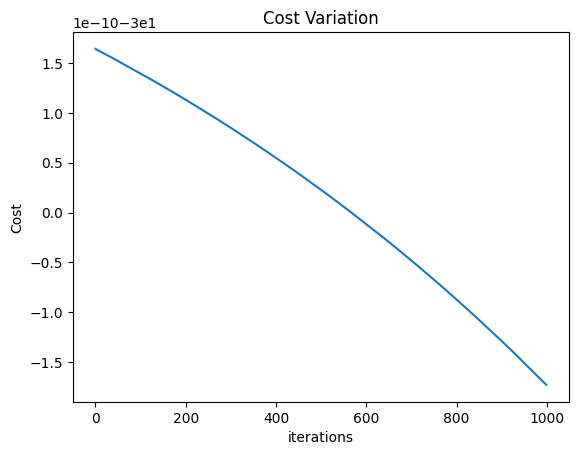

In [34]:
plt.plot(cost_history)
plt.title("Cost Variation")
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.show()

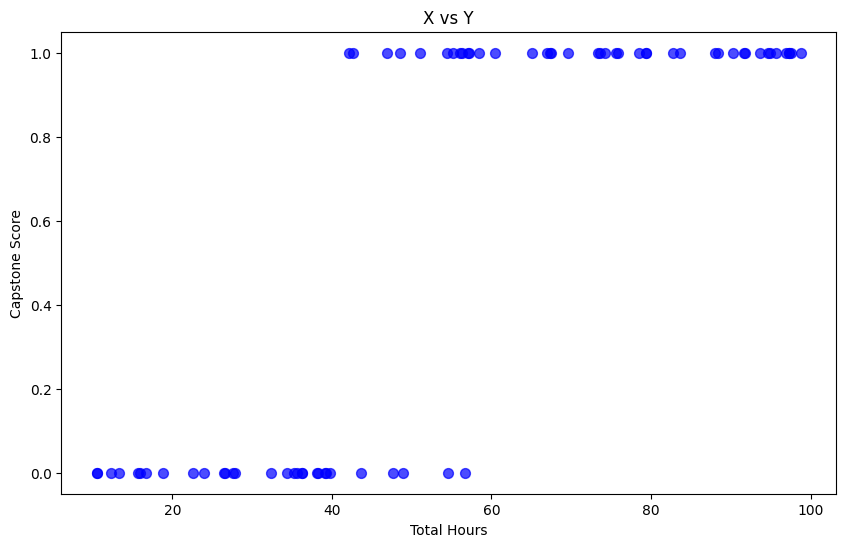

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.7, color='blue', s=50)
plt.xlabel('Total Hours')
plt.ylabel('Capstone Score')
plt.title('X vs Y')
plt.show()

In [36]:
def compute_cost(X, Y, beta):
    """ 
        X : (m, n)
        Y : (m, )
        beta : (beta0, beta1)

        MSE = >  sum(( y_hat - y ) ** 2)
        X.dot(beta) => beta0 + beta1.x1 + ...... + betaj.xj + ...... + betan.xn   
    """

    m= len(Y)
    y_hat = X.dot(beta)
    cost = ( 1 / (2 * m) ) * np.sum((y_hat - Y) ** 2)
    return cost

def gradient_descent(X, Y, beta, lr, n_iter):
    """ 
    X : (m, n) -> after adding bias : (m, n+1) -> (72, 2) | If I take transpose -> (2, 72)

    dj/dbetaj = (1 / m) * X.T * (y_hat - y)
    """

    m = len(Y)
    cost_history = []

    for i in range(n_iter):

        y_hat = X.dot(beta)
        gradients = (1 / m) * X.T.dot(y_hat - Y)

        beta = beta - lr * gradients
        cost = compute_cost(X, Y, beta)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration: {i}: cost: {cost:.4f} ")

    return cost_history,beta     

In [37]:
""" 
    y_hat = beta0.x0 + beta1.x1; xo = 1
    X = [1, x1]

"""


X_with_bias = np.column_stack([np.ones((len(X))), X])
X_with_bias

array([[ 1. , 43.7],
       [ 1. , 95.6],
       [ 1. , 75.9],
       [ 1. , 24. ],
       [ 1. , 88. ],
       [ 1. , 97.3],
       [ 1. , 26.5],
       [ 1. , 57.2],
       [ 1. , 48.9],
       [ 1. , 36.2],
       [ 1. , 65.1],
       [ 1. , 22.6],
       [ 1. , 36.3],
       [ 1. , 51. ],
       [ 1. , 56.3],
       [ 1. , 15.9],
       [ 1. , 96.9],
       [ 1. , 18.8],
       [ 1. , 54.6],
       [ 1. , 91.8],
       [ 1. , 69.6],
       [ 1. , 38.1],
       [ 1. , 26.6],
       [ 1. , 97.3],
       [ 1. , 94.6],
       [ 1. , 27.6],
       [ 1. , 39.3],
       [ 1. , 34.4],
       [ 1. , 42.1],
       [ 1. , 35.3],
       [ 1. , 98.8],
       [ 1. , 27.9],
       [ 1. , 10.5],
       [ 1. , 73.6],
       [ 1. , 75.6],
       [ 1. , 79.4],
       [ 1. , 16.7],
       [ 1. , 39.8],
       [ 1. , 15.7],
       [ 1. , 67.4],
       [ 1. , 74.2],
       [ 1. , 78.5],
       [ 1. , 60.5],
       [ 1. , 79.4],
       [ 1. , 54.4],
       [ 1. , 57. ],
       [ 1. , 48.5],
       [ 1. ,

In [38]:
beta = np.random.randn(2)
print(f"beta values : {beta}")

lr = 0.000001
n_iter = 10000

beta values : [ 1.53828412 -1.25576699]


In [39]:
cost_history, beta = gradient_descent(X_with_bias, Y, beta, lr, n_iter)

Iteration: 0: cost: 2958.4059 
Iteration: 100: cost: 1367.9905 
Iteration: 200: cost: 632.6688 
Iteration: 300: cost: 292.6959 
Iteration: 400: cost: 135.5108 
Iteration: 500: cost: 62.8370 
Iteration: 600: cost: 29.2366 
Iteration: 700: cost: 13.7015 
Iteration: 800: cost: 6.5190 
Iteration: 900: cost: 3.1981 
Iteration: 1000: cost: 1.6628 
Iteration: 1100: cost: 0.9529 
Iteration: 1200: cost: 0.6247 
Iteration: 1300: cost: 0.4729 
Iteration: 1400: cost: 0.4027 
Iteration: 1500: cost: 0.3703 
Iteration: 1600: cost: 0.3553 
Iteration: 1700: cost: 0.3483 
Iteration: 1800: cost: 0.3451 
Iteration: 1900: cost: 0.3436 
Iteration: 2000: cost: 0.3429 
Iteration: 2100: cost: 0.3426 
Iteration: 2200: cost: 0.3424 
Iteration: 2300: cost: 0.3424 
Iteration: 2400: cost: 0.3423 
Iteration: 2500: cost: 0.3423 
Iteration: 2600: cost: 0.3423 
Iteration: 2700: cost: 0.3423 
Iteration: 2800: cost: 0.3423 
Iteration: 2900: cost: 0.3422 
Iteration: 3000: cost: 0.3422 
Iteration: 3100: cost: 0.3422 
Itera

In [40]:
print(f"beat beta : {beta}")

beat beta : [ 1.55312992 -0.01140583]


In [41]:
x_min, x_max = float(np.min(X)), float(np.max(X))
x_interval = np.linspace(x_min, x_max, 100)
x_interval_with_bias = np.column_stack([np.ones((len(x_interval))), x_interval])
y_hat_interval = x_interval_with_bias.dot(beta)
y_hat_interval

array([1.43336874, 1.42319566, 1.41302258, 1.40284951, 1.39267643,
       1.38250336, 1.37233028, 1.3621572 , 1.35198413, 1.34181105,
       1.33163798, 1.3214649 , 1.31129183, 1.30111875, 1.29094567,
       1.2807726 , 1.27059952, 1.26042645, 1.25025337, 1.24008029,
       1.22990722, 1.21973414, 1.20956107, 1.19938799, 1.18921491,
       1.17904184, 1.16886876, 1.15869569, 1.14852261, 1.13834954,
       1.12817646, 1.11800338, 1.10783031, 1.09765723, 1.08748416,
       1.07731108, 1.067138  , 1.05696493, 1.04679185, 1.03661878,
       1.0264457 , 1.01627262, 1.00609955, 0.99592647, 0.9857534 ,
       0.97558032, 0.96540725, 0.95523417, 0.94506109, 0.93488802,
       0.92471494, 0.91454187, 0.90436879, 0.89419571, 0.88402264,
       0.87384956, 0.86367649, 0.85350341, 0.84333033, 0.83315726,
       0.82298418, 0.81281111, 0.80263803, 0.79246495, 0.78229188,
       0.7721188 , 0.76194573, 0.75177265, 0.74159958, 0.7314265 ,
       0.72125342, 0.71108035, 0.70090727, 0.6907342 , 0.68056

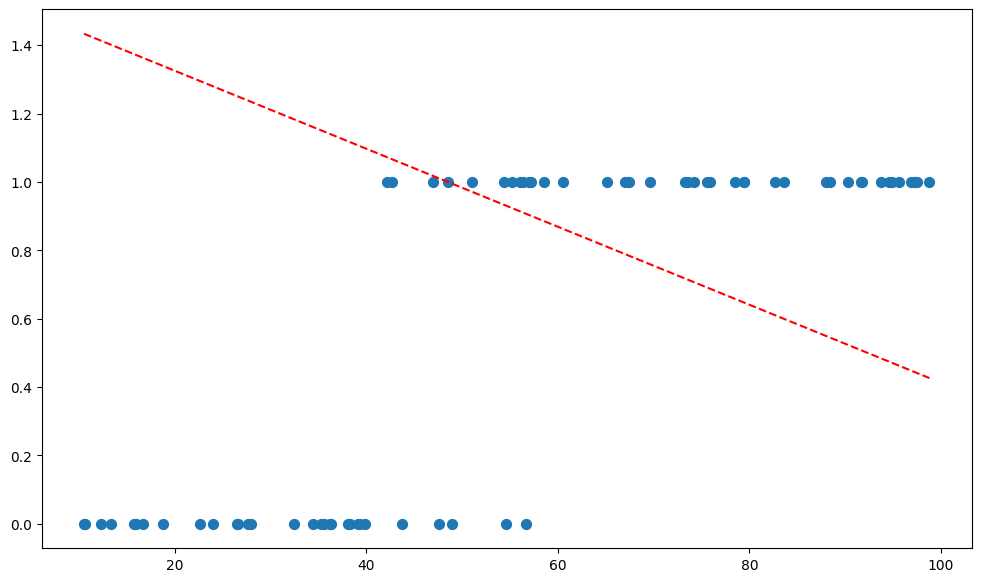

In [42]:
plt.figure(figsize=(12, 7))

plt.scatter(X, Y, s=50, label="actual data")

plt.plot(x_interval, y_hat_interval, 'r--', label="fitted line")

plt.show()

##### how to evaluate ?

    - MSE : Mean squared error
    - RMSE : Root mean squared error
    - MAE : Mean absolute error
    - R^2 : R-squared

In [43]:
Y_hat = X_with_bias.dot(beta)
Y_hat

array([1.05469528, 0.46273287, 0.68742766, 1.27939007, 0.54941715,
       0.44334296, 1.25087551, 0.90071662, 0.99538498, 1.14023899,
       0.81061059, 1.29535823, 1.1390984 , 0.97143275, 0.91098187,
       1.37177727, 0.44790529, 1.33870037, 0.93037177, 0.50607501,
       0.75928437, 1.11856791, 1.24973492, 0.44334296, 0.4741387 ,
       1.2383291 , 1.10488092, 1.16076947, 1.07294461, 1.15050423,
       0.42623422, 1.23490735, 1.43336874, 0.71366106, 0.69084941,
       0.64750726, 1.36265261, 1.09917801, 1.37405844, 0.78437719,
       0.70681756, 0.65777251, 0.86307739, 0.64750726, 0.93265294,
       0.90299779, 0.99994731, 1.41283825, 0.78551777, 1.11628675,
       0.50721559, 1.18358113, 1.01819664, 0.48440394, 0.78893952,
       0.54485482, 0.52318375, 0.88588905, 0.60986804, 0.59960279,
       1.43222815, 0.91440361, 1.01021256, 0.47071695, 1.10716209,
       0.90641953, 0.71708281, 1.06610111, 0.4410618 , 1.14708248,
       1.40143242, 0.92352827])

In [44]:
def MSE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.mean(e_i**2)

def MAE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.mean(np.abs(e_i))

def R2_Score(Y,Y_hat):
    y_mean = np.mean(Y)
    e_i = Y - Y_hat
    std_i = Y - y_mean

    E = np.sum(e_i**2) / np.sum(std_i ** 2)
    return 1 - E

def RMSE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.sqrt(np.mean((Y - Y_hat) ** 2))           

In [45]:
mse = MSE(Y, Y_hat)
mae = MAE(Y, Y_hat)
r2 = R2_Score(Y, Y_hat)
rmse = RMSE(Y,Y_hat)

print(f"MSE : {mse}")
print(f"MAE : {mae}")
print(f"R2 Score : {r2}")
print(f"RMSE : {rmse}")

MSE : 0.6829478413170692
MAE : 0.6758367900152593
R2 Score : -1.8098425471330848
RMSE : 0.8264065835392825
